<a href="https://colab.research.google.com/github/ShahSayem/Alzheimer-Disease-Detection/blob/main/1A-Alzheimer_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
borhanitrash_alzheimer_mri_disease_classification_dataset_path = kagglehub.dataset_download('borhanitrash/alzheimer-mri-disease-classification-dataset')

print('Data source import complete.')


In [ ]:
import torch
import tqdm
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.optim import lr_scheduler
import torch.backends.cudnn as cudnn
from torch.utils.data import Dataset, DataLoader
import numpy as np
import pandas as pd
import cv2
import torchvision
from torchvision import datasets, models, transforms
from torchvision.transforms import v2
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import time
import os
import PIL
from PIL import Image
cudnn.benchmark = True

device = (
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Using {device} device")

Using cpu device


In [ ]:
BASE_DIR = "/kaggle/input/alzheimer-mri-disease-classification-dataset/Alzheimer MRI Disease Classification Dataset/Data/"
disease_label_from_category = {
    0: "Mild Demented",
    1: "Moderate Demented",
    2: "Non Demented",
    3: "Very Mild Demented",
}

In [ ]:
df = pd.read_parquet(f"{BASE_DIR}/train-00000-of-00001-c08a401c53fe5312.parquet", engine="pyarrow")
df.head()

,image,label
0,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,2
1,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,0
2,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,3
3,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,3
4,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,2


In [ ]:
test = pd.read_parquet(f"{BASE_DIR}/test-00000-of-00001-44110b9df98c5585.parquet", engine="pyarrow")

In [ ]:
def dict_to_image(image_dict):
    if isinstance(image_dict, dict) and 'bytes' in image_dict:
        byte_string = image_dict['bytes']
        nparr = np.frombuffer(byte_string, np.uint8)
        img = cv2.imdecode(nparr, cv2.IMREAD_GRAYSCALE)
        return img
    else:
        raise TypeError(f"Expected dictionary with 'bytes' key, got {type(image_dict)}")

In [ ]:
df['img_arr'] = df['image'].apply(dict_to_image)
df.drop("image", axis=1, inplace=True)
df.head()

,label,img_arr
0,2,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,..."
1,0,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,..."
2,3,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,..."
3,3,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,..."
4,2,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,..."


In [ ]:
test['img_arr'] = test['image'].apply(dict_to_image)
test.drop("image", axis=1, inplace=True)

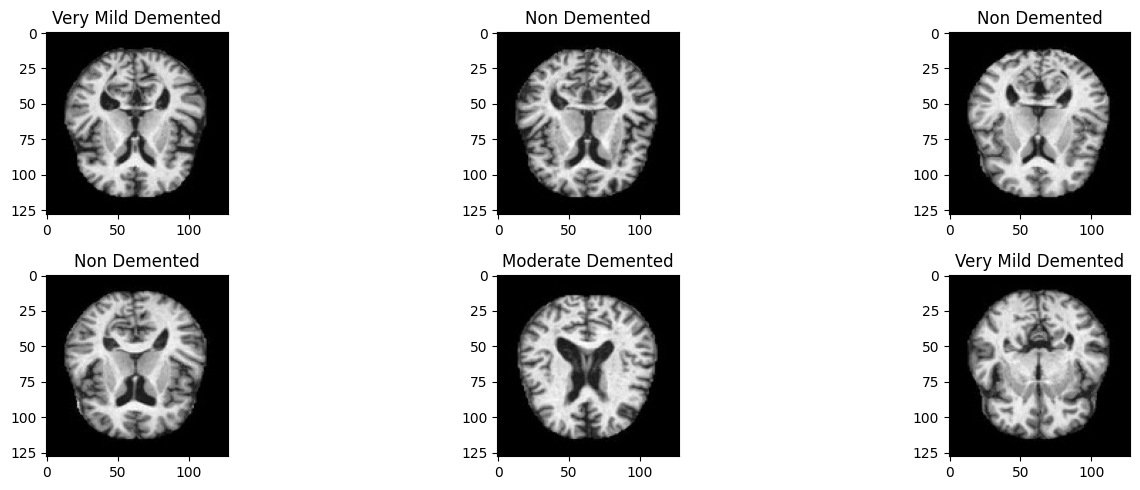

In [ ]:
# Check we can actually render the image and that it looks reasonable
fig, ax = plt.subplots(2, 3, figsize=(15, 5))
axs = ax.flatten()
for axes in axs:
    rand = np.random.randint(0, len(df))
    axes.imshow(df.iloc[rand]['img_arr'], cmap="gray")
    axes.set_title(disease_label_from_category[df.iloc[rand]['label']])
plt.tight_layout()
plt.show()

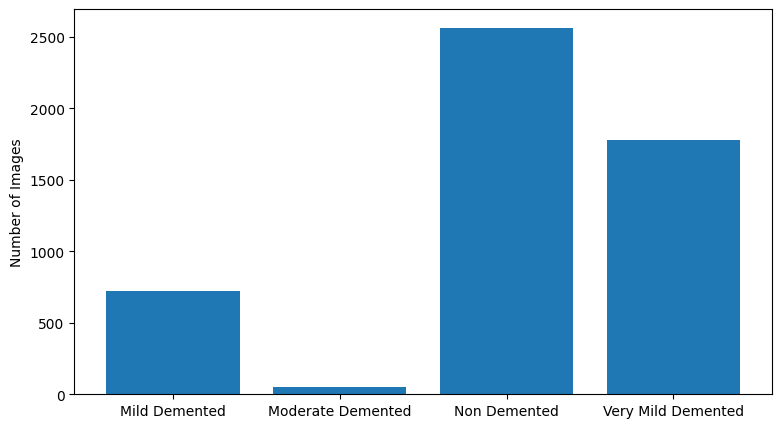

Total samples in training data = 5120


In [ ]:
plt.figure(figsize=(9, 5))
plt.bar(np.arange(0, 4, 1), df['label'].value_counts().sort_index())
plt.ylabel("Number of Images")
plt.xticks(np.arange(0, 4, 1), labels=[disease_label_from_category[i] for i in range(4)])
plt.show()
print(f"Total samples in training data = {len(df)}")

In [ ]:
N_CLASSES = df['label'].nunique()

In [ ]:
# Use a torch dataset/dataloader to handle feeding our data in the model
class ImageDataset(Dataset):
    def __init__(self, dataframe):
        self.dataframe = dataframe

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        image = self.dataframe.iloc[idx]["img_arr"] # Get the img numpy array from the df
        label = self.dataframe.iloc[idx]["label"] # Get the label from the df
        # The CNN requires we add a channel dimension i.e. (128, 128) -> (1, 128, 128)
        image = torch.tensor(image, dtype=torch.float32).unsqueeze(0)
        label = torch.tensor(label, dtype=torch.long)
        return image, label

In [ ]:
class BaselineCNN(nn.Module):
    # Basic CNN using 2D convolutional layers, some max pooling and
    # a single batch normalisation layer to counter overfitting. We used a linear (dense)
    # layer as the output with the output shape being the number of classes
    def __init__(self):
        super(BaselineCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.pool1 = nn.MaxPool2d(2, 2)
        self.batchnorm1 = nn.BatchNorm2d(num_features=32)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool2 = nn.MaxPool2d(2, 2)
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(64 * 32 * 32, 128)
        self.out = nn.Linear(128, N_CLASSES)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = self.pool1(x)
        x = self.batchnorm1(x)
        x = F.relu(self.conv2(x))
        x = self.pool2(x)
        x = self.flatten(x)
        x = F.relu(self.fc1(x))
        x = self.out(x)
        return x

In [ ]:
# Hyperparameters, I did a few training iterations and found these to be good
learning_rate = 0.001
NEPOCHS = 10
batch_size = 32

In [ ]:
# Create dataset and dataloader
train_dataset = ImageDataset(df)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

In [ ]:
def train_model(model, loader, optimizer, num_epochs=NEPOCHS):
    # Initialize model, loss function, and optimizer
    criterion = nn.CrossEntropyLoss()

    # Training loop
    train_losses = []
    for epoch in tqdm.tqdm(range(num_epochs), total=num_epochs):
        running_loss = 0.0
        for i, data in enumerate(loader, 0):
            inputs, labels = data[0].to(device), data[1].to(device)
            # zero the parameter gradients
            optimizer.zero_grad()
            # forward + backward + optimize
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            # print statistics
            running_loss += loss.item()
        epoch_loss = running_loss / len(loader)
        train_losses.append(epoch_loss)

    print('Finished Training')
    return model, train_losses

In [ ]:
model = BaselineCNN().to(device)
optimizer = optim.AdamW(model.parameters(), lr=learning_rate)
model, train_losses = train_model(model, train_loader, optimizer)

100%|██████████| 10/10 [16:33<00:00, 99.38s/it]

Finished Training


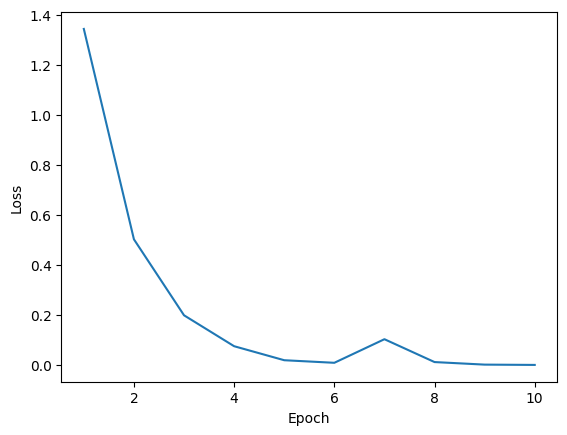

In [ ]:
plt.plot(np.arange(1, 11), train_losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

In [ ]:
def predict(m, dl, device):
    m.eval()  # Set model to evaluation mode
    predictions = []
    true_labels = []

    with torch.no_grad():  # Disable gradient computation for inference
        for images, labels in dl:
            images = images.to(device)
            outputs = m(images)
            _, preds = torch.max(outputs, 1)  # Get the index of the max log-probability
            predictions.extend(preds.cpu().numpy())
            true_labels.extend(labels.cpu().numpy())

    return predictions, true_labels

def result_summary(predictions, true_labels):
    # Accuracy
    accuracy = accuracy_score(true_labels, predictions)
    print(f'Accuracy: {accuracy:.4f}')

    # Confusion Matrix
    conf_matrix = confusion_matrix(true_labels, predictions)
    print('Confusion Matrix:')
    print(conf_matrix)

    # Precision, Recall, F1 Score
    #class_report = classification_report(true_labels, predictions, target_names=['Class 0', 'Class 1', 'Class 2', 'Class 3'])
    #print('Classification Report:')
    #print(class_report)

In [ ]:
# Lets display some basic summary statistics to see how we did
# Note: this is dreadful practice to evaluate on the training data but this won't be our
# final model and is just for demonstration purposes!
predictions, true_labels = predict(model, train_loader, device)
result_summary(predictions, true_labels)

Accuracy: 1.0000
Confusion Matrix:
[[ 724    0    0    0]
 [   0   49    0    0]
 [   0    0 2566    0]
 [   0    0    0 1781]]


In [ ]:
# Run the same report on the test data
test_dataset = ImageDataset(test)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
predictions_test, test_labels = predict(model, test_loader, device)

result_summary(predictions_test, test_labels)

Accuracy: 0.9789
Confusion Matrix:
[[161   0   6   5]
 [  0  14   0   1]
 [  0   0 627   7]
 [  0   0   8 451]]


Improvement 1: **Image Augmentation**

In [ ]:
# Use a torch dataset/dataloader to handle feeding our data in the model
class ImageDataset(Dataset):
    def __init__(self, dataframe, transform):
        self.dataframe = dataframe
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        image = self.dataframe.iloc[idx]["img_arr"]
        label = self.dataframe.iloc[idx]["label"]

        if self.transform:
            image = image.astype(np.uint8)
            image = self.transform(image)

        label = torch.tensor(label, dtype=torch.long)
        image = torch.tensor(image, dtype=torch.float32).unsqueeze(0)

        return image, label

In [ ]:
transforms = v2.Compose([
    v2.RandomHorizontalFlip(p=0.3), # Horizontally flip with 30% probability
    v2.RandomVerticalFlip(p=0.3), # Vertical flip with 30% probability
    v2.GaussianBlur(kernel_size=3), # Blur the images using a Gaussian kernel
    v2.RandomRotation(degrees=(-45, 45)), # Randomly rotate the images
    v2.ToDtype(torch.float32, scale=True), # Upated version of ToTensor
    v2.Normalize(mean=[0.485], std=[0.229]), # Only 1 channel in the image
])

In [ ]:
train_dataset = ImageDataset(df, transforms) # Needed as we changed the defn of ImageDataset
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

In [ ]:
# The only thing I have changed is adding transforms (+5 epochs of train time)
model_aug = BaselineCNN().to(device)
optimizer = optim.AdamW(model_aug.parameters(), lr=learning_rate)
model_aug, train_losses_aug = train_model(model_aug, train_loader, optimizer, num_epochs=15)

100%|██████████| 15/15 [22:58<00:00, 91.89s/it]

Finished Training


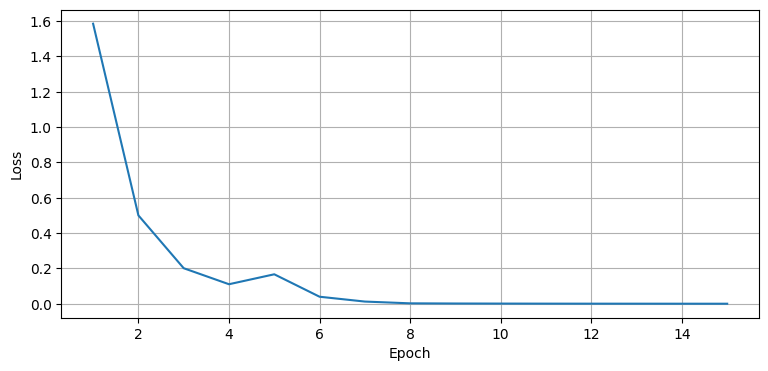

In [ ]:
plt.figure(figsize=(9,4))
plt.plot(np.arange(1, 15+1), train_losses_aug)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid()
plt.show()

In [ ]:
# Do not apply augmentation when generating predictions for evaluation of model performance
train_dataset_notf = ImageDataset(df, None)
train_loader_notf = DataLoader(train_dataset_notf, batch_size=batch_size, shuffle=True)

train_predictions, train_labels = predict(model_aug, train_loader_notf, device)
test_predictions, test_labels = predict(model_aug, test_loader, device)

In [ ]:
result_summary(train_predictions, train_labels)

Accuracy: 1.0000
Confusion Matrix:
[[ 724    0    0    0]
 [   0   49    0    0]
 [   0    0 2566    0]
 [   0    0    0 1781]]


In [ ]:
result_summary(test_predictions, test_labels)

Accuracy: 0.9773
Confusion Matrix:
[[160   0   4   8]
 [  0  13   0   2]
 [  0   0 631   3]
 [  0   0  12 447]]
